MODELE DE RESEAU DE NEURONES CONVOLUTIFS

In [14]:
'''

Modèle KNN

'''

'\n\nModèle KNN\n\n'

In [15]:
# Import des librairies principales
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf


# Imports nécessaires pour créer, sauvegarder et évaluer le modèle
from sklearn.neighbors import KNeighborsClassifier

import joblib

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix


# Importation de l'utilitaire image_dataset_from_directory de Keras
from keras.utils import image_dataset_from_directory


In [16]:
# Définition des chemins d'accès

rep_img = 'C:\\Users\\Utilisateur\\Documents\\DataScience_images_Especes\\' # Chemin vers l'ensemble des images de champignons
rep_model = "C:\\Users\\Utilisateur\\Documents\\DataScience\\avr25cds_reconnaissance_champignons\\models\\" # Chemin vers les sauvegardes de modèles


In [17]:
# Importation de l'utilitaire image_dataset_from_directory de Keras


train_ds = image_dataset_from_directory(
    rep_img,
    validation_split=0.2,       # Fraction des données utilisée pour la validation
    subset="training",          # Charger les données d'entraînement
    seed=42,                    # Graine pour le découpage des données
    batch_size=64,  #128        # Taille des lots
    image_size=(224, 224)       # Redimensionnement des images
)

val_ds = image_dataset_from_directory(
    rep_img,
    validation_split=0.2,       # Fraction des données utilisée pour la validation
    subset="validation",              # Charger les données de validation
    seed=42,
    batch_size=64,
    image_size=(224, 224)  
)


Found 19216 files belonging to 30 classes.
Using 15373 files for training.
Found 19216 files belonging to 30 classes.
Using 3843 files for validation.


In [18]:
# Nombre de lot dans l'ensemble d'entraînement
print("Nombre de batch dans train_ds:", train_ds.cardinality().numpy())

# Nombre de lot dans l'ensemble de validation
print("Nombre de batch dans val_ds:", val_ds.cardinality().numpy())

Nombre de batch dans train_ds: 241
Nombre de batch dans val_ds: 61


In [19]:
# Normalisation
train_ds = train_ds.map(lambda x, y: (x / 255.0, y))
val_ds = val_ds.map(lambda x, y: (x / 255.0, y))

In [20]:
# Extraction des images et labels
def dataset_to_numpy(dataset):
    images, labels = [], []
    for batch_images, batch_labels in dataset:
        images.append(batch_images.numpy())
        labels.append(batch_labels.numpy())
    return np.concatenate(images), np.concatenate(labels)

X_train, y_train = dataset_to_numpy(train_ds)
X_val, y_val = dataset_to_numpy(val_ds)

In [21]:
# Aplatissement des images pour scikit-learn
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)

print("Shape des données :", X_train_flat.shape)

# Passage en float16 pour diviser par 2 la taille
X_train_flat = X_train_flat.astype(np.float16, copy=False)
X_val_flat   = X_val_flat.astype(np.float16, copy=False)

print("Shape des données :", X_train_flat.shape)


Shape des données : (15373, 150528)
Shape des données : (15373, 150528)


In [22]:
# Modèle KNN


knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_flat, y_train)

y_pred = knn.predict(X_val_flat)
print("Accuracy KNN :", accuracy_score(y_val, y_pred))


Accuracy KNN : 0.3257871454592766


In [23]:
# Ecrasement de l'arbre avant la sauvegarde pour gagner de la place
knn._tree = None

# Sauvegarde avec compression zstd

joblib.dump(knn, rep_model+"KNN_model.pkl", compress=("lzma", 3))


['C:\\Users\\Utilisateur\\Documents\\DataScience\\avr25cds_reconnaissance_champignons\\models\\KNN_model.pkl']

<Axes: >

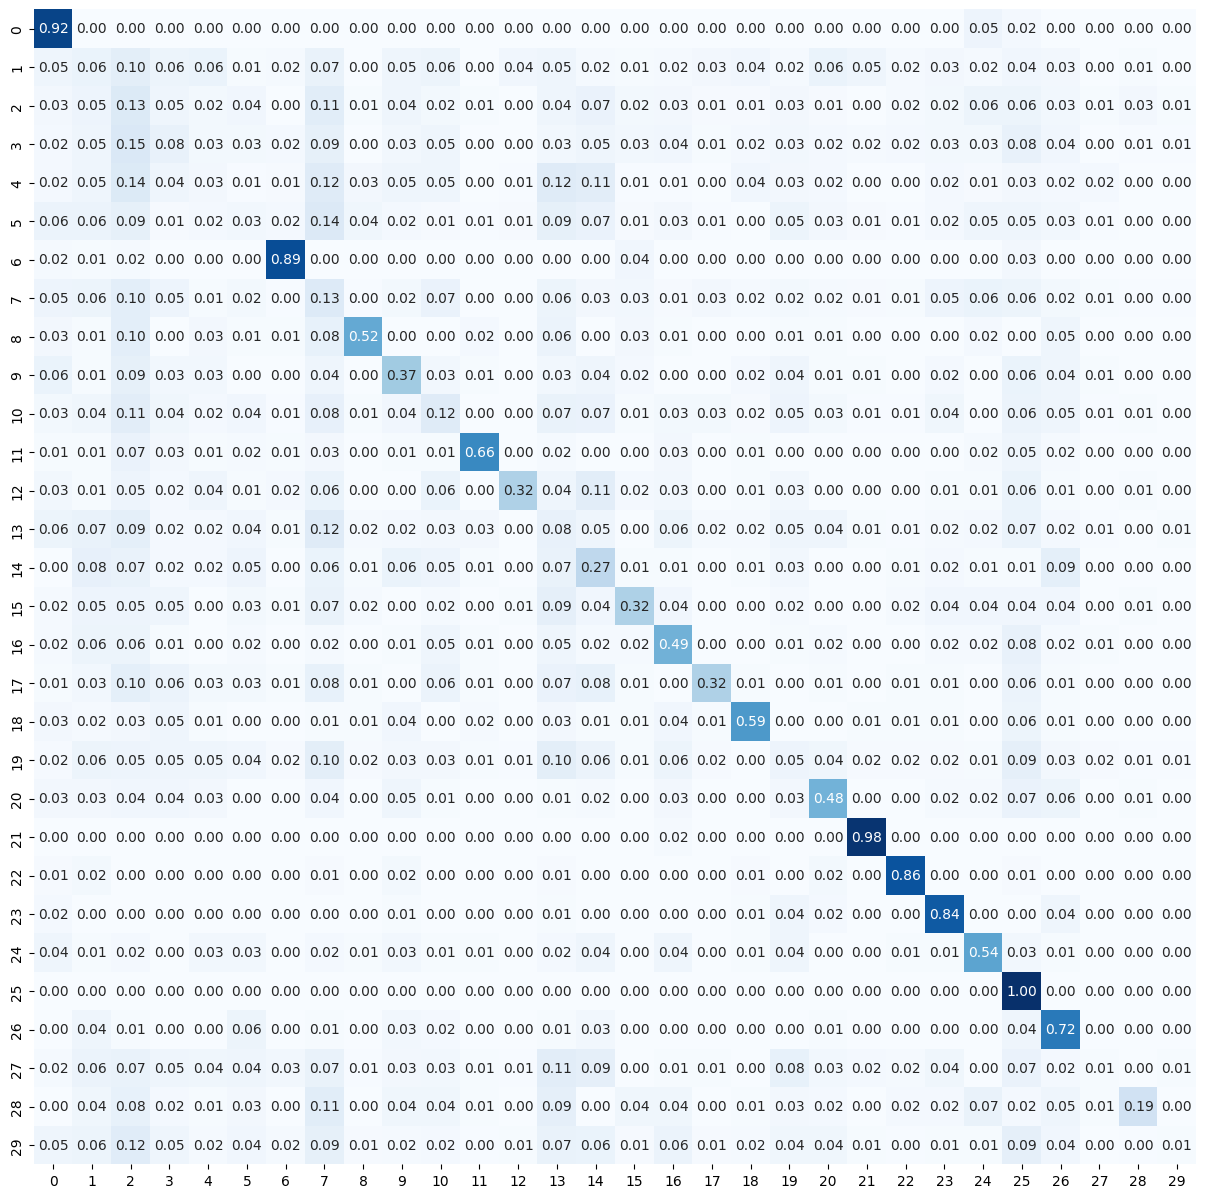

In [11]:
# Affichage de la matrice de confusion
plt.figure(figsize=(15, 15))
cnf_matrix_knn = confusion_matrix(y_val, y_pred, normalize='true')
sns.heatmap(cnf_matrix_knn, cmap='Blues', annot=True, cbar=False, fmt=".2f")